# Options pricing with Black-Scholes
This notebook demonstrates a selection of capabilities of the **Volaris** library:
- option pricing with the Black-Scholes model
- Greeks calculation: delta, gamma, vega, theta, rho
- fast root-finding and numerical integration through a compiled C core
- binomial tree as a discrete alternative to Black-Scholes

---

In [1]:
library(Volaris)
S <- 100.0; K <- 100.0; T <- 1.0; r <- 0.05; sigma <- 0.20

---

## Black-Scholes pricing

The Black-Scholes model assumes the underlying option follows Geometric Brownian Motion.

Variables used:
| Symbol | Meaning | Example value |
|--------|---------|---------------|
| S | current price of the underlying asset | 100.0 |
| K | strike price (exercise price of the option) | 100.0 |
| T | time to expiration in years | 1.0 (= 1 year) |
| r | risk-free interest rate (annualised) | 0.05 (= 5%) |
| sigma | volatility of the underlying (annualised) | 0.20 (= 20%) |
| C | call option price: right to buy at K | computed |
| P | put option price: right to sell at K | computed |

Call and put prices for an at-the-money option, verified via put-call parity:

In [2]:
call <- bs_price(S, K, T, r, sigma, 1)
put <- bs_price(S, K, T, r, sigma, 0)
cat(sprintf("Call: %.4f\n", call))
cat(sprintf("Put:  %.4f\n", put))
cat(sprintf("Put-call parity check: %.4f vs %.4f\n", call - put, S - K * exp(-r * T)))
if (abs((call - put) - (S - K * exp(-r * T))) < 1e-10) cat("Put-call parity holds!\n")

Call: 10.4506
Put:  5.5735
Put-call parity check: 4.8771 vs 4.8771
Put-call parity holds!


---

## Greeks calculation

The Greeks measure the sensitivity of the option price to market parameters.

Below: delta, gamma, vega, and theta for call and put options as a function of spot price S.

In [3]:
spots <- seq(60, 140, length.out = 200)
deltas_c <- sapply(spots, function(s) bs_delta(s, K, T, r, sigma, 1))
deltas_p <- sapply(spots, function(s) bs_delta(s, K, T, r, sigma, 0))
gammas <- sapply(spots, function(s) bs_gamma(s, K, T, r, sigma))
vegas <- sapply(spots, function(s) bs_vega(s, K, T, r, sigma))
thetas_c <- sapply(spots, function(s) bs_theta(s, K, T, r, sigma, 1))
thetas_p <- sapply(spots, function(s) bs_theta(s, K, T, r, sigma, 0))

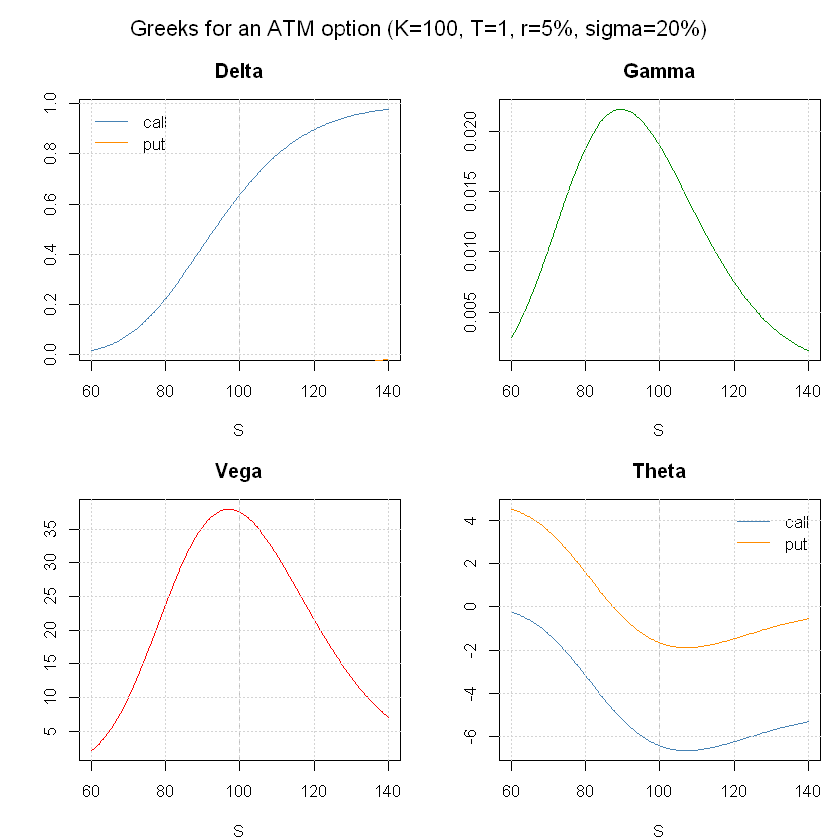

In [ ]:
par(mfrow = c(2, 2), mar = c(4, 4, 3, 1), oma = c(0, 0, 2, 0))
plot(spots, deltas_c, type="l", col="steelblue", xlab="S", ylab="", main="Delta")
lines(spots, deltas_p, col="darkorange")
abline(v=K, lty=2, col="gray")
legend("topleft", c("call","put"), col=c("steelblue","darkorange"), lty=1, bty="n")
grid()
plot(spots, gammas, type="l", col="green4", xlab="S", ylab="", main="Gamma")
abline(v=K, lty=2, col="gray")
grid()
plot(spots, vegas, type="l", col="red", xlab="S", ylab="", main="Vega")
abline(v=K, lty=2, col="gray")
grid()
plot(spots, thetas_c, type="l", col="steelblue", xlab="S", ylab="", main="Theta", ylim=range(c(thetas_c, thetas_p)))
lines(spots, thetas_p, col="darkorange")
abline(v=K, lty=2, col="gray")
legend("topright", c("call","put"), col=c("steelblue","darkorange"), lty=1, bty="n")
grid()
mtext("Greeks for an ATM option (K=100, T=1, r=5%, sigma=20%)", outer=TRUE, cex=1.1)
par(mfrow=c(1,1))

---

## Root-finding

Volaris provides two root-finding methods implemented in C.

Example: find sigma such that the BS call price equals 15. This is also exactly what `implied_vol` does internally.


In [5]:
target <- 15.0
f <- function(sig) bs_price(S, K, T, r, sig, 1) - target
df <- function(sig) bs_vega(S, K, T, r, sig)
root_newton <- rootfind_newton(f, df, x0 = 0.3)
root_bisect <- rootfind_bisect(f, 0.01, 2.0)
iv <- implied_vol(target, S, K, T, r, 1)
cat(sprintf("Target: %g\n------------------\n", target))
cat(sprintf("Newton-Raphson:  sigma = %.6f  |  price = %.6f\n", root_newton, bs_price(S,K,T,r,root_newton,1)))
cat(sprintf("Bisection:       sigma = %.6f  |  price = %.6f\n", root_bisect, bs_price(S,K,T,r,root_bisect,1)))
cat(sprintf("Implied vol:     sigma = %.6f  |  price = %.6f\n", iv, bs_price(S,K,T,r,iv,1)))

Target: 15
------------------
Newton-Raphson:  sigma = 0.320258  |  price = 15.000000
Bisection:       sigma = 0.320258  |  price = 15.000000
Implied vol:     sigma = 0.320258  |  price = 15.000000


---

## Numerical integration

The Black-Scholes formula is derived from an integral over the normal distribution.

Comparison of Gauss quadrature (custom C implementation) and GSL QAGS adaptive integration:

In [6]:
normal_pdf <- function(x) exp(-0.5 * x * x) / sqrt(2 * pi)
a <- -3.0; b <- 3.0
exact <- 0.9973002039
result_gauss <- integrate_gauss(normal_pdf, a, b, n_points = 20L)
result_gsl   <- integrate_gsl(normal_pdf, a, b, tol = 1e-10)
cat(sprintf("Gauss quadrature (n=20): %.10f  |  error: %.2e\n", result_gauss, abs(result_gauss - exact)))
cat(sprintf("GSL QAGS:                %.10f  |  error: %.2e\n", result_gsl, abs(result_gsl - exact)))
cat(sprintf("Exact value:             %.10f\n", exact))

Gauss quadrature (n=20): 0.9973002039  |  error: 3.67e-11
GSL QAGS:                0.9973002039  |  error: 3.67e-11
Exact value:             0.9973002039


---

## Options pricing with a binomial tree

The Cox-Ross-Rubinstein model demonstrates Brownian motion on a binomial tree.

As the number of steps N increases, the price converges to the Black-Scholes analytical value:

In [7]:
bs_ref <- bs_price(S, K, T, r, sigma, 1)
steps <- c(5, 10, 20, 50, 100, 200, 500)
prices <- sapply(steps, function(N) binomial_price(S, K, T, r, 0.0, sigma, N, 1, 0))

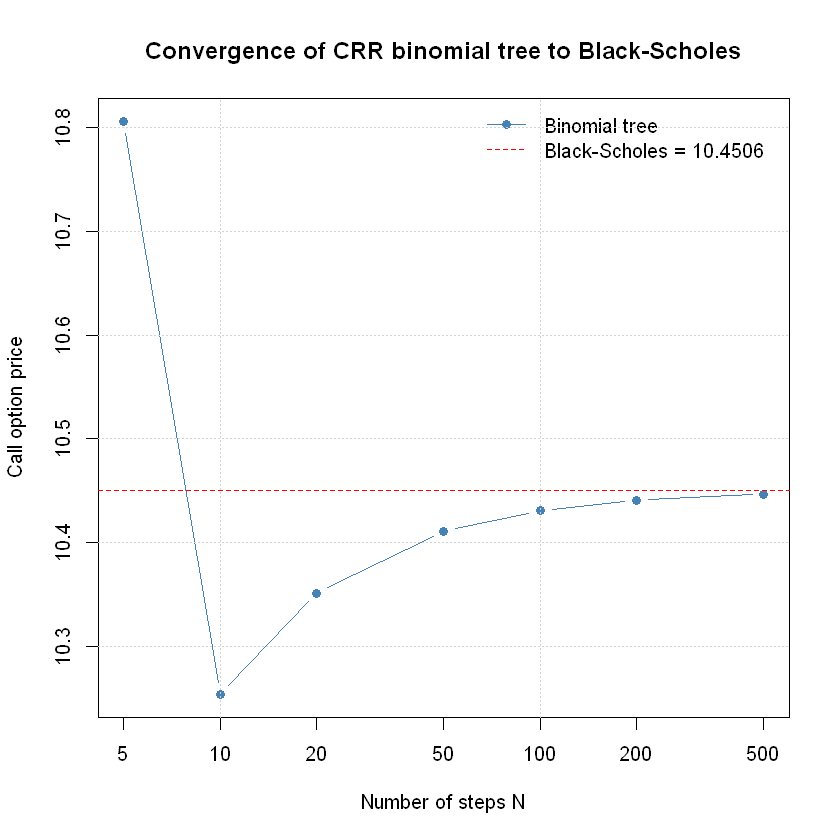

In [8]:
plot(steps, prices, log="x", type="b", pch=19, col="steelblue", 
     xlab="Number of steps N", ylab="Call option price",
     main="Convergence of CRR binomial tree to Black-Scholes")
abline(h=bs_ref, col="red", lty=2)
legend("topright", c("Binomial tree", sprintf("Black-Scholes = %.4f", bs_ref)),
       col=c("steelblue","red"), lty=c(1,2), pch=c(19,NA), bty="n"); grid()